# **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import zipfile
import os
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense , Dropout , Activation , Flatten
from keras.layers import Conv2D , MaxPooling2D , GlobalMaxPooling2D , BatchNormalization

# **Functions**

In [ ]:
def acc_plot(model):
    plt.figure(figsize = (10,6))
    sns.set_style('whitegrid')
    plt.plot(model.history['accuracy'] , color = '#E74C3C' , marker = 'o')
    plt.plot(model.history['val_accuracy'] , color = '#641E16' , marker = 'h')
    plt.title('Accuracy comparison between Validation and Train data' , fontsize = 15)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train' , 'Test'] , loc = 'lower right')
    plt.show()

In [ ]:
def loss_plot(model):
    plt.figure(figsize = (10,6))
    sns.set_style('whitegrid')
    plt.plot(model.history['loss'] , color = 'Purple' , marker = 'o')
    plt.plot(model.history['val_loss'] , color = 'Orange' , marker = 'h')
    plt.title('Loss comparison between Validation and Train data' , fontsize = 15)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train' , 'Test'] , loc = 'lower right')
    plt.show()

# **Data Preprocessing**

## **Import Dataset**

In [ ]:
zip_path = "Dataset.zip"
extract_path = "Dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = extract_path

## **Show Dataset**

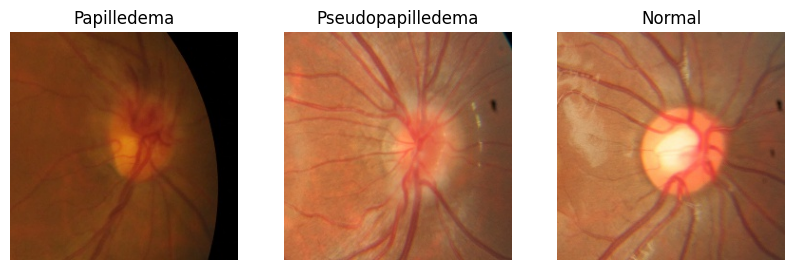

In [ ]:
class_names = os.listdir(dataset_path)
class_names = [cls for cls in class_names if os.path.isdir(os.path.join(dataset_path, cls))]

plt.figure(figsize=(10, 10))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
image_size = (255, 255)
data = []
labels = []

for label, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path).resize(image_size)
        data.append(np.array(image))
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Initial data shape")
print(f"Data shape: {data.shape}, labels shape: {labels.shape}")

Initial data shape
Data shape: (1369, 255, 255, 3), labels shape: (1369,)


## **Normalization**

In [ ]:
data = data / 255.0

## **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print(f"X_train.shape: {X_train.shape}, X_test.shape: {X_test.shape}")

X_train.shape: (1095, 255, 255, 3), X_test.shape: (274, 255, 255, 3)


## **Check Imbalancing**

Data distribution: Counter({2: 624, 0: 241, 1: 230})


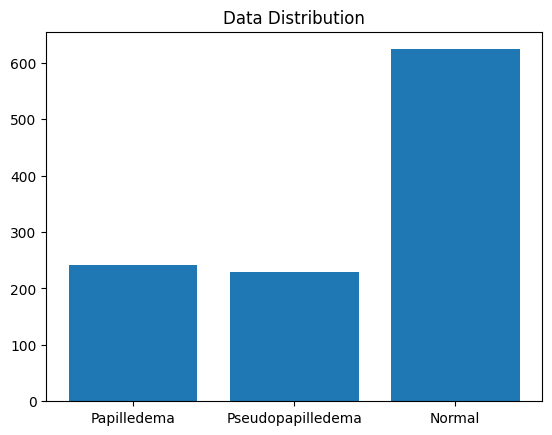

In [ ]:
class_counts = Counter(y_train)
print("Data distribution:", class_counts)

unique, counts = np.unique(y_train, return_counts=True)
plt.bar(class_names, counts)
plt.title("Data Distribution")
plt.show()

## **Balance Data**

In [ ]:
# Target data for each class
target_count = 624

balanced_X_train = []
balanced_y_train = []

for img, label in zip(X_train, y_train):
    balanced_X_train.append(img)
    balanced_y_train.append(label)

# Generate new data
datagen = ImageDataGenerator(horizontal_flip=True)

for class_label, count in class_counts.items():
    if count < target_count:
        class_images = X_train[y_train == class_label]
        images_to_generate = target_count - count

        for i in range(images_to_generate):
            img = np.expand_dims(class_images[i % count], 0)
            augmented_image = datagen.flow(img, batch_size=1)[0]
            balanced_X_train.append(augmented_image[0])
            balanced_y_train.append(class_label)

balanced_X_train = np.array(balanced_X_train)
balanced_y_train = np.array(balanced_y_train)


unique, counts = np.unique(balanced_y_train, return_counts=True)
print("Data distribution", dict(zip(unique, counts)))


Data distribution {0: 624, 1: 624, 2: 624}


# **CNN Models**

In [ ]:
model1 = Sequential()

model1.add(Conv2D(32, (3, 3), activation='relu', input_shape=(255, 255, 3)))
model1.add(MaxPooling2D((2, 2)))
model1.add(Dropout(0.35))

model1.add(Conv2D(64, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(Dropout(0.35))

model1.add(Conv2D(128, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(Dropout(0.35))

model1.add(Conv2D(256, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(Dropout(0.35))

model1.add(Flatten())

model1.add(Dense(128, activation='relu'))
model1.add(Dropout(0.5))

model1.add(Dense(64, activation='relu'))
model1.add(Dropout(0.5))

model1.add(Dense(3, activation='softmax')) #Output Layer

model1.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model1.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 253, 253, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 126, 126, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 126, 126, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 124, 124, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,819,523 (26.01 MB)

 Trainable params: 6,819,523 (26.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train, num_classes=3)
y_test_encoded = to_categorical(y_test, num_classes=3)

In [ ]:
m1 = model1.fit(balanced_X_train , balanced_y_train , batch_size = 30 , epochs = 25 ,
              validation_data = (X_test , y_test_encoded) , shuffle = True)

Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 226s 6s/step - accuracy: 0.4424 - loss: 1.4142 - val_accuracy: 0.5657 - val_loss: 1.0226
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 249s 6s/step - accuracy: 0.5629 - loss: 0.9810 - val_accuracy: 0.5657 - val_loss: 0.9445
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 208s 6s/step - accuracy: 0.5640 - loss: 0.8362 - val_accuracy: 0.5657 - val_loss: 0.8042
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 262s 6s/step - accuracy: 0.5918 - loss: 0.7290 - val_accuracy: 0.6934 - val_loss: 0.7604
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 263s 6s/step - accuracy: 0.6500 - loss: 0.7020 - val_accuracy: 0.5109 - val_loss: 0.9385
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 263s 6s/step - accuracy: 0.6854 - loss: 0.7167 - val_accuracy: 0.7007 - val_loss: 0.6760
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 261s 6s/step - accuracy: 0.7323 - loss: 0.6519 - val_accuracy: 0.6095 - val_loss: 0.7815
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 261s 6s/step - accuracy: 0.7307 - loss: 0.6665 - val_accuracy: 0.5949 - v

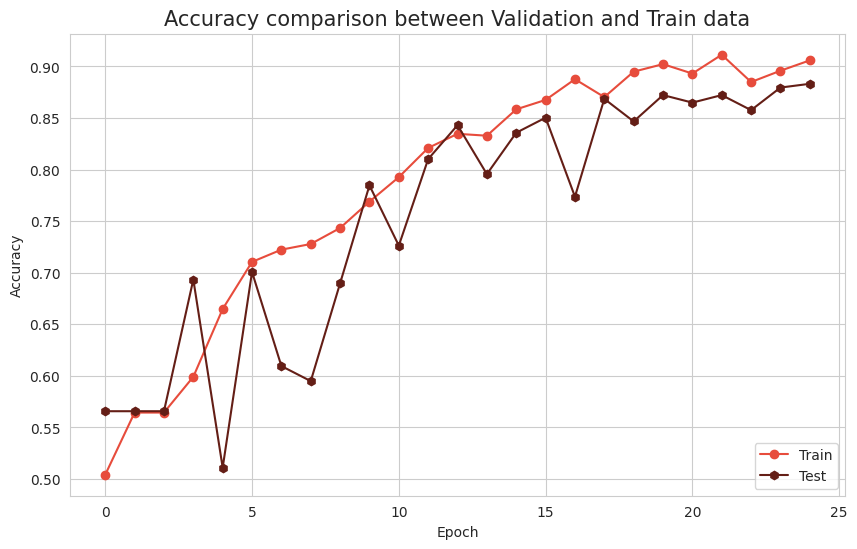

In [ ]:
acc_plot(m1)

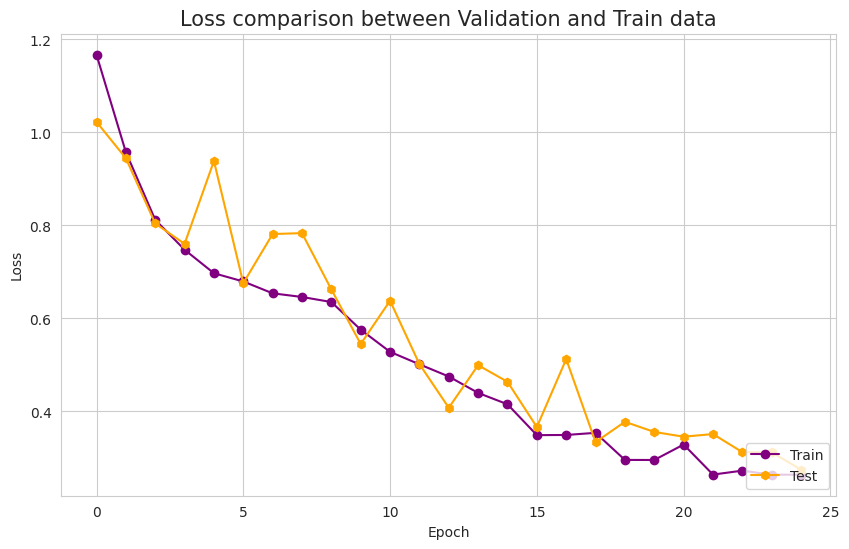

In [ ]:
loss_plot(m1)